# EffiSense — Sequence-Based Productivity Modeling
## LSTM and GRU

This notebook extends the previous model comparison:

**Linear Regression → Random Forest → XGBoost → LSTM → GRU**

### Objective
Predict the mouse-behavior-derived **Behavioral Productivity Index (BPI)** using temporal sequences of consecutive behavioral windows.

### Important interpretation
The target is the constructed `productivity_score` / BPI.  
Therefore, model performance measures how well the model reproduces the behavior-derived score.

It does **not** independently validate real-world employee productivity until external productivity ground truth is available.

## 1. Experimental design

Each row represents one behavioral window.

The windows are highly overlapping, so random row-wise splitting would cause leakage.

Therefore:

- Sequence windows are created **inside each `(user, session)`**
- A sequence never crosses a session boundary
- `GroupKFold` uses `(user, session)` as the group
- The scaler is fitted only on the training fold
- The same folds are used for LSTM and GRU
- Evaluation uses MAE, MSE, RMSE and R²

In [2]:
# If TensorFlow is not installed, uncomment and run:
%pip install tensorflow scikit-learn pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Num GPUs:", len(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.21.0
Num GPUs: 0


## 2. Load the reduced productivity dataset

Expected file:

`data/processed/mouse_productivity_scores_reduced.csv`

The reduced dataset contains 14 behavioral features plus the identifiers and target.

In [4]:
DATA_PATH = r"C:/Users/muskan/OneDrive/Desktop/effisense/data/processed/mouse_productivity_scores_reduced.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Shape: (10000, 18)

Columns:
['user', 'session', 'window_id', 'idle_percentage', 'pause_count', 'mean_pause', 'mean_velocity', 'total_distance', 'mean_distance', 'velocity_cv', 'velocity_entropy', 'smoothness', 'mean_acceleration', 'std_acceleration', 'mean_direction_change', 'direction_entropy', 'num_events', 'productivity_score']


,user,session,window_id,idle_percentage,pause_count,mean_pause,mean_velocity,total_distance,mean_distance,velocity_cv,velocity_entropy,smoothness,mean_acceleration,std_acceleration,mean_direction_change,direction_entropy,num_events,productivity_score
0,1,0,0,89.174232,10,19.121272,578.583333,15579.0,421.054054,1.184911,2.473445,0.457684,-597.442062,2120.227750,42.500000,3.770910,50,36.182450
1,1,0,1,83.134215,9,12.858115,556.828571,13258.0,368.277778,1.253838,2.303159,0.443688,-680.170202,2168.037515,48.257143,3.489738,50,40.649101
2,1,3,0,53.829371,4,7.256878,420.945946,13122.0,345.315789,0.566635,3.622182,0.638311,-402.997322,1023.699837,44.405405,3.349761,50,83.235344
3,1,3,1,53.164829,4,7.256878,409.285714,12611.0,350.305556,0.596354,3.544027,0.626428,-337.542845,926.733476,46.828571,3.220465,50,81.675943
4,1,3,2,53.441885,5,6.235818,432.885714,14059.0,390.527778,0.573483,3.518868,0.635533,-232.205140,683.374185,47.400000,3.313182,50,82.509975


In [5]:
print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).head(20))

print("\nUsers:", df["user"].nunique())
print("User-session groups:", df.groupby(["user", "session"]).ngroups)
print("Score range:", df["productivity_score"].min(), "to", df["productivity_score"].max())

Missing values:


user                     0
session                  0
window_id                0
idle_percentage          0
pause_count              0
mean_pause               0
mean_velocity            0
total_distance           0
mean_distance            0
velocity_cv              0
velocity_entropy         0
smoothness               0
mean_acceleration        0
std_acceleration         0
mean_direction_change    0
direction_entropy        0
num_events               0
productivity_score       0
dtype: int64


Users: 9
User-session groups: 91
Score range: 0.0 to 100.0


## 3. Define the 14 behavioral features

These are the same reduced features used for Linear Regression, Random Forest and XGBoost.

In [6]:
FEATURES = [
    "idle_percentage",
    "pause_count",
    "mean_pause",
    "mean_velocity",
    "total_distance",
    "mean_distance",
    "velocity_cv",
    "velocity_entropy",
    "smoothness",
    "mean_acceleration",
    "std_acceleration",
    "mean_direction_change",
    "direction_entropy",
    "num_events"
]

TARGET = "productivity_score"

GROUP_COLUMNS = ["user", "session"]

required_columns = FEATURES + [TARGET] + GROUP_COLUMNS + ["window_id"]

missing = [c for c in required_columns if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Number of features:", len(FEATURES))
print(FEATURES)

Number of features: 14
['idle_percentage', 'pause_count', 'mean_pause', 'mean_velocity', 'total_distance', 'mean_distance', 'velocity_cv', 'velocity_entropy', 'smoothness', 'mean_acceleration', 'std_acceleration', 'mean_direction_change', 'direction_entropy', 'num_events']


## 4. Clean and order the behavioral windows

For sequence modeling, ordering matters.

We sort by:

1. user
2. session
3. window_id

If `window_id` is numeric, it represents the temporal order of the behavioral windows within the session.

In [7]:
df = df.copy()

df["user"] = df["user"].astype(str)
df["session"] = df["session"].astype(str)

df["window_id"] = pd.to_numeric(df["window_id"], errors="coerce")

df = df.dropna(subset=FEATURES + [TARGET, "window_id"]).copy()

df = df.sort_values(
    ["user", "session", "window_id"]
).reset_index(drop=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (10000, 18)


## 5. Check session sizes

A sequence length of 10 requires at least 10 consecutive windows in a session.

We inspect the distribution before creating sequences.

In [8]:
session_sizes = (
    df.groupby(["user", "session"])
      .size()
      .rename("n_windows")
)

display(session_sizes.describe())

print("Sessions:", len(session_sizes))
print("Sessions with >= 10 windows:", (session_sizes >= 10).sum())
print("Sessions with < 10 windows:", (session_sizes < 10).sum())

count     91.000000
mean     109.890110
std      144.130069
min        1.000000
25%       22.500000
50%       54.000000
75%      158.000000
max      754.000000
Name: n_windows, dtype: float64

Sessions: 91
Sessions with >= 10 windows: 77
Sessions with < 10 windows: 14


## 6. Sequence configuration

Each training example contains:

**10 consecutive behavioral windows × 14 features**

The target is the BPI of the **last window** in the sequence.

Example:

`Window 1 → Window 2 → ... → Window 10 → predict score of Window 10`

Then the next sequence can be:

`Window 2 → Window 3 → ... → Window 11 → predict score of Window 11`

This preserves temporal information while keeping the prediction target aligned with the final window.

In [9]:
SEQUENCE_LENGTH = 10
STRIDE = 1

print("Sequence length:", SEQUENCE_LENGTH)
print("Sequence stride:", STRIDE)

Sequence length: 10
Sequence stride: 1


## 7. Group identifiers

A group is one complete `(user, session)`.

This is critical because the same session must never appear partly in training and partly in testing.

In [10]:
df["group_id"] = (
    df["user"].astype(str) + "__" +
    df["session"].astype(str)
)

print("Unique groups:", df["group_id"].nunique())
display(df[["user", "session", "group_id"]].drop_duplicates().head())

Unique groups: 91


,user,session,group_id
0,1,0,1__0
2,1,13,1__13
10,1,17,1__17
52,1,18,1__18
80,1,19,1__19


## 8. Helper: create sequences

This function:

- receives already-selected data
- processes one `(user, session)` at a time
- sorts windows chronologically
- creates sequences only inside that session
- never lets a sequence cross into another session

The target is the score of the final window.

In [11]:
def make_sequences(data, feature_columns, target_column,
                   sequence_length=10, stride=1):
    X_sequences = []
    y_sequences = []
    sequence_groups = []

    data = data.sort_values(
        ["user", "session", "window_id"]
    )

    for (user, session), group in data.groupby(
        ["user", "session"], sort=False
    ):
        group = group.sort_values("window_id")

        X_values = group[feature_columns].to_numpy(dtype=np.float32)
        y_values = group[target_column].to_numpy(dtype=np.float32)

        n = len(group)

        if n < sequence_length:
            continue

        for start in range(0, n - sequence_length + 1, stride):
            end = start + sequence_length

            X_sequences.append(X_values[start:end])
            y_sequences.append(y_values[end - 1])

            sequence_groups.append(f"{user}__{session}")

    if not X_sequences:
        return (
            np.empty((0, sequence_length, len(feature_columns)), dtype=np.float32),
            np.empty((0,), dtype=np.float32),
            np.array([], dtype=object)
        )

    return (
        np.asarray(X_sequences, dtype=np.float32),
        np.asarray(y_sequences, dtype=np.float32),
        np.asarray(sequence_groups, dtype=object)
    )

## 9. Verify sequence construction on the complete dataset

This is only a structural check.

**We do not use these complete-data sequences for model evaluation**, because scaling and fold separation must happen inside each CV fold.

In [12]:
X_check, y_check, groups_check = make_sequences(
    df,
    FEATURES,
    TARGET,
    sequence_length=SEQUENCE_LENGTH,
    stride=STRIDE
)

print("Sequence tensor shape:", X_check.shape)
print("Target shape:", y_check.shape)
print("Unique sequence groups:", len(np.unique(groups_check)))

Sequence tensor shape: (9242, 10, 14)
Target shape: (9242,)
Unique sequence groups: 77


## 10. Leakage-safe fold preparation

For every fold:

1. Split whole `(user, session)` groups into train/test.
2. Fit `StandardScaler` using **training windows only**.
3. Transform train and test windows using that scaler.
4. Create sequences separately inside train and test.
5. Train the neural network only on training sequences.
6. Evaluate only on test sequences.

This prevents information from the test sessions from influencing preprocessing.

In [13]:
def scale_and_sequence_fold(train_df, test_df,
                             feature_columns, target_column,
                             sequence_length=10, stride=1):

    train_df = train_df.copy()
    test_df = test_df.copy()

    scaler = StandardScaler()

    train_df[feature_columns] = scaler.fit_transform(
        train_df[feature_columns]
    )

    test_df[feature_columns] = scaler.transform(
        test_df[feature_columns]
    )

    X_train, y_train, train_groups = make_sequences(
        train_df,
        feature_columns,
        target_column,
        sequence_length,
        stride
    )

    X_test, y_test, test_groups = make_sequences(
        test_df,
        feature_columns,
        target_column,
        sequence_length,
        stride
    )

    return (
        X_train, y_train, train_groups,
        X_test, y_test, test_groups,
        scaler
    )

## 11. LSTM model

Architecture:

- LSTM(64)
- Dropout(0.20)
- Dense(32, ReLU)
- Dense(1)

The output is a single continuous BPI score.

In [14]:
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(
            64,
            input_shape=input_shape,
            return_sequences=False
        ),
        Dropout(0.20),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


# Quick architecture check
test_model = build_lstm_model(
    (SEQUENCE_LENGTH, len(FEATURES))
)

test_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,337 (87.25 KB)

 Trainable params: 22,337 (87.25 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Evaluation helper

In [15]:
def calculate_metrics(y_true, y_pred):
    y_pred = np.asarray(y_pred).reshape(-1)

    # BPI is defined on 0–100, so predictions are clipped
    # to the valid score range for the reported evaluation.
    y_pred_clipped = np.clip(y_pred, 0, 100)

    mae = mean_absolute_error(y_true, y_pred_clipped)
    mse = mean_squared_error(y_true, y_pred_clipped)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred_clipped)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

# 13. LSTM — 5-Fold GroupKFold

The same 5-fold group strategy used for the previous models is used here.

Because the number of sessions is relatively small, each fold may contain different numbers of sequence examples.

In [16]:
N_SPLITS = 5

groups = df["group_id"].values

gkf = GroupKFold(
    n_splits=N_SPLITS
)

lstm_fold_results = []
lstm_predictions = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df, df[TARGET], groups=groups),
    start=1
):
    print("=" * 70)
    print(f"LSTM FOLD {fold}/{N_SPLITS}")

    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()

    train_groups = set(train_df["group_id"])
    test_groups = set(test_df["group_id"])

    overlap = train_groups.intersection(test_groups)

    print("Train sessions:", len(train_groups))
    print("Test sessions :", len(test_groups))
    print("Group overlap :", len(overlap))

    if overlap:
        raise RuntimeError("LEAKAGE DETECTED: train/test groups overlap.")

    (
        X_train, y_train, train_sequence_groups,
        X_test, y_test, test_sequence_groups,
        scaler
    ) = scale_and_sequence_fold(
        train_df,
        test_df,
        FEATURES,
        TARGET,
        sequence_length=SEQUENCE_LENGTH,
        stride=STRIDE
    )

    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)

    if len(X_train) == 0 or len(X_test) == 0:
        print("Skipping fold because a split has no usable sequences.")
        continue

    model = build_lstm_model(
        (X_train.shape[1], X_train.shape[2])
    )

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=0
        )
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.10,
        epochs=30,
        batch_size=64,
        callbacks=callbacks,
        verbose=0
    )

    y_pred = model.predict(
        X_test,
        verbose=0
    ).reshape(-1)

    metrics = calculate_metrics(y_test, y_pred)

    metrics["Fold"] = fold
    metrics["Train_Sequences"] = len(X_train)
    metrics["Test_Sequences"] = len(X_test)
    metrics["Epochs_Run"] = len(history.history["loss"])

    lstm_fold_results.append(metrics)

    lstm_predictions.append(
        pd.DataFrame({
            "fold": fold,
            "group_id": test_sequence_groups,
            "y_true": y_test,
            "y_pred": np.clip(y_pred, 0, 100)
        })
    )

    print(
        f"MAE  : {metrics['MAE']:.4f}\n"
        f"MSE  : {metrics['MSE']:.4f}\n"
        f"RMSE : {metrics['RMSE']:.4f}\n"
        f"R²   : {metrics['R2']:.4f}"
    )

    tf.keras.backend.clear_session()

LSTM FOLD 1/5
Train sessions: 74
Test sessions : 17
Group overlap : 0
X_train: (7388, 10, 14)
X_test : (1854, 10, 14)
MAE  : 1.6249
MSE  : 5.7355
RMSE : 2.3949
R²   : 0.9907

LSTM FOLD 2/5
Train sessions: 73
Test sessions : 18
Group overlap : 0
X_train: (7395, 10, 14)
X_test : (1847, 10, 14)
MAE  : 1.3176
MSE  : 3.5307
RMSE : 1.8790
R²   : 0.9940
LSTM FOLD 3/5
Train sessions: 73
Test sessions : 18
Group overlap : 0
X_train: (7393, 10, 14)
X_test : (1849, 10, 14)
MAE  : 1.2630
MSE  : 2.8538
RMSE : 1.6893
R²   : 0.9915
LSTM FOLD 4/5
Train sessions: 72
Test sessions : 19
Group overlap : 0
X_train: (7396, 10, 14)
X_test : (1846, 10, 14)
MAE  : 1.0547
MSE  : 2.2163
RMSE : 1.4887
R²   : 0.9962
LSTM FOLD 5/5
Train sessions: 72
Test sessions : 19
Group overlap : 0
X_train: (7396, 10, 14)
X_test : (1846, 10, 14)
MAE  : 1.0079
MSE  : 1.8705
RMSE : 1.3677
R²   : 0.9967


## 14. LSTM results

In [17]:
lstm_results_df = pd.DataFrame(lstm_fold_results)

display(lstm_results_df)

if len(lstm_results_df):
    lstm_summary = pd.DataFrame({
        "Metric": ["MAE", "MSE", "RMSE", "R²"],
        "Mean": [
            lstm_results_df["MAE"].mean(),
            lstm_results_df["MSE"].mean(),
            lstm_results_df["RMSE"].mean(),
            lstm_results_df["R2"].mean()
        ],
        "Std": [
            lstm_results_df["MAE"].std(),
            lstm_results_df["MSE"].std(),
            lstm_results_df["RMSE"].std(),
            lstm_results_df["R2"].std()
        ]
    })

    display(lstm_summary)

,MAE,MSE,RMSE,R2,Fold,Train_Sequences,Test_Sequences,Epochs_Run
0,1.624907,5.735484,2.394887,0.990700,1,7388,1854,19
1,1.317573,3.530723,1.879022,0.993953,2,7395,1847,20
2,1.262981,2.853792,1.689317,0.991468,3,7393,1849,16
3,1.054677,2.216300,1.488724,0.996157,4,7396,1846,28
4,1.007906,1.870495,1.367660,0.996695,5,7396,1846,30


,Metric,Mean,Std
0,MAE,1.253609,0.245960
1,MSE,3.241359,1.531716
2,RMSE,1.763922,0.403016
3,R²,0.993795,0.002693


## 15. Plot LSTM training history

The history from the final completed fold is shown here as a sanity check.

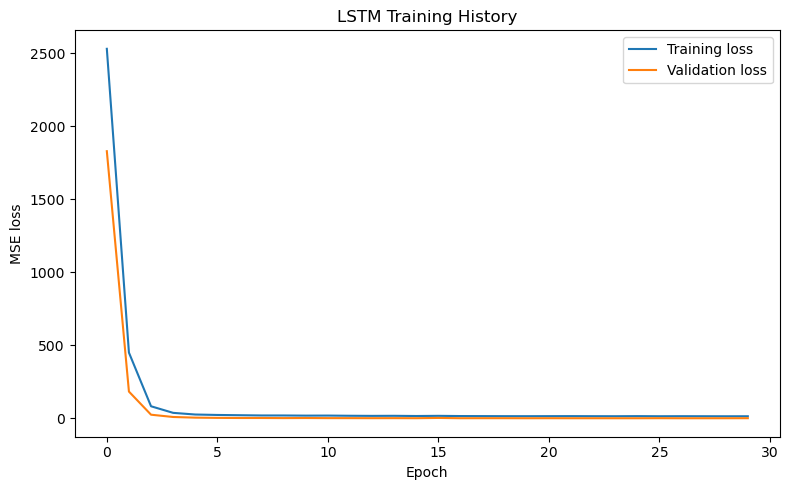

In [18]:
if "history" in globals():
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title("LSTM Training History")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 16. GRU model

GRU is a gated recurrent architecture similar to LSTM but simpler.

We keep the architecture and training procedure as comparable as possible:

- GRU(64)
- Dropout(0.20)
- Dense(32)
- Dense(1)

In [19]:
def build_gru_model(input_shape):
    model = Sequential([
        GRU(
            64,
            input_shape=input_shape,
            return_sequences=False
        ),
        Dropout(0.20),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


test_model = build_gru_model(
    (SEQUENCE_LENGTH, len(FEATURES))
)

test_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        15,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,473 (68.25 KB)

 Trainable params: 17,473 (68.25 KB)

 Non-trainable params: 0 (0.00 B)

# 17. GRU — 5-Fold GroupKFold

In [20]:
gru_fold_results = []
gru_predictions = []

# Re-create the exact same folds
gkf = GroupKFold(
    n_splits=N_SPLITS
)

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df, df[TARGET], groups=groups),
    start=1
):
    print("=" * 70)
    print(f"GRU FOLD {fold}/{N_SPLITS}")

    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()

    train_groups = set(train_df["group_id"])
    test_groups = set(test_df["group_id"])

    overlap = train_groups.intersection(test_groups)

    print("Train sessions:", len(train_groups))
    print("Test sessions :", len(test_groups))
    print("Group overlap :", len(overlap))

    if overlap:
        raise RuntimeError("LEAKAGE DETECTED: train/test groups overlap.")

    (
        X_train, y_train, train_sequence_groups,
        X_test, y_test, test_sequence_groups,
        scaler
    ) = scale_and_sequence_fold(
        train_df,
        test_df,
        FEATURES,
        TARGET,
        sequence_length=SEQUENCE_LENGTH,
        stride=STRIDE
    )

    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)

    if len(X_train) == 0 or len(X_test) == 0:
        print("Skipping fold because a split has no usable sequences.")
        continue

    model = build_gru_model(
        (X_train.shape[1], X_train.shape[2])
    )

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=0
        )
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.10,
        epochs=30,
        batch_size=64,
        callbacks=callbacks,
        verbose=0
    )

    y_pred = model.predict(
        X_test,
        verbose=0
    ).reshape(-1)

    metrics = calculate_metrics(y_test, y_pred)

    metrics["Fold"] = fold
    metrics["Train_Sequences"] = len(X_train)
    metrics["Test_Sequences"] = len(X_test)
    metrics["Epochs_Run"] = len(history.history["loss"])

    gru_fold_results.append(metrics)

    gru_predictions.append(
        pd.DataFrame({
            "fold": fold,
            "group_id": test_sequence_groups,
            "y_true": y_test,
            "y_pred": np.clip(y_pred, 0, 100)
        })
    )

    print(
        f"MAE  : {metrics['MAE']:.4f}\n"
        f"MSE  : {metrics['MSE']:.4f}\n"
        f"RMSE : {metrics['RMSE']:.4f}\n"
        f"R²   : {metrics['R2']:.4f}"
    )

    tf.keras.backend.clear_session()

GRU FOLD 1/5
Train sessions: 74
Test sessions : 17
Group overlap : 0
X_train: (7388, 10, 14)
X_test : (1854, 10, 14)
MAE  : 1.7589
MSE  : 6.3013
RMSE : 2.5102
R²   : 0.9898
GRU FOLD 2/5
Train sessions: 73
Test sessions : 18
Group overlap : 0
X_train: (7395, 10, 14)
X_test : (1847, 10, 14)
MAE  : 1.2955
MSE  : 3.0994
RMSE : 1.7605
R²   : 0.9947
GRU FOLD 3/5
Train sessions: 73
Test sessions : 18
Group overlap : 0
X_train: (7393, 10, 14)
X_test : (1849, 10, 14)
MAE  : 1.0618
MSE  : 2.3251
RMSE : 1.5248
R²   : 0.9930
GRU FOLD 4/5
Train sessions: 72
Test sessions : 19
Group overlap : 0
X_train: (7396, 10, 14)
X_test : (1846, 10, 14)
MAE  : 1.0567
MSE  : 2.2286
RMSE : 1.4928
R²   : 0.9961
GRU FOLD 5/5
Train sessions: 72
Test sessions : 19
Group overlap : 0
X_train: (7396, 10, 14)
X_test : (1846, 10, 14)
MAE  : 1.1065
MSE  : 2.2810
RMSE : 1.5103
R²   : 0.9960


## 18. GRU results

In [21]:
gru_results_df = pd.DataFrame(gru_fold_results)

display(gru_results_df)

if len(gru_results_df):
    gru_summary = pd.DataFrame({
        "Metric": ["MAE", "MSE", "RMSE", "R²"],
        "Mean": [
            gru_results_df["MAE"].mean(),
            gru_results_df["MSE"].mean(),
            gru_results_df["RMSE"].mean(),
            gru_results_df["R2"].mean()
        ],
        "Std": [
            gru_results_df["MAE"].std(),
            gru_results_df["MSE"].std(),
            gru_results_df["RMSE"].std(),
            gru_results_df["R2"].std()
        ]
    })

    display(gru_summary)

,MAE,MSE,RMSE,R2,Fold,Train_Sequences,Test_Sequences,Epochs_Run
0,1.758899,6.301252,2.510230,0.989783,1,7388,1854,17
1,1.295465,3.099369,1.760503,0.994692,2,7395,1847,19
2,1.061768,2.325086,1.524823,0.993049,3,7393,1849,17
3,1.056742,2.228593,1.492847,0.996136,4,7396,1846,18
4,1.106522,2.281046,1.510313,0.995969,5,7396,1846,27


,Metric,Mean,Std
0,MAE,1.255879,0.297590
1,MSE,3.247069,1.744305
2,RMSE,1.759743,0.433551
3,R²,0.993926,0.002626


# 19. Model comparison

The previous experiments produced:

- Linear Regression
- Random Forest
- XGBoost

We add LSTM and GRU to the same comparison table.

**Do not rank models solely by R².** Look at MAE and RMSE as well.

In [22]:
previous_results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": 1.7621,
        "RMSE": 2.3862,
        "R2": 0.9927
    },
    {
        "Model": "Random Forest",
        "MAE": 1.3161,
        "RMSE": 1.7113,
        "R2": 0.9943
    },
    {
        "Model": "XGBoost",
        "MAE": 0.8064,
        "RMSE": 1.0891,
        "R2": 0.9977
    }
])

comparison_rows = previous_results.to_dict("records")

if len(lstm_results_df):
    comparison_rows.append({
        "Model": "LSTM",
        "MAE": lstm_results_df["MAE"].mean(),
        "RMSE": lstm_results_df["RMSE"].mean(),
        "R2": lstm_results_df["R2"].mean()
    })

if len(gru_results_df):
    comparison_rows.append({
        "Model": "GRU",
        "MAE": gru_results_df["MAE"].mean(),
        "RMSE": gru_results_df["RMSE"].mean(),
        "R2": gru_results_df["R2"].mean()
    })

comparison_df = pd.DataFrame(comparison_rows)

display(
    comparison_df.sort_values(
        "MAE",
        ascending=True
    ).reset_index(drop=True)
)

,Model,MAE,RMSE,R2
0,XGBoost,0.806400,1.089100,0.997700
1,LSTM,1.253609,1.763922,0.993795
2,GRU,1.255879,1.759743,0.993926
3,Random Forest,1.316100,1.711300,0.994300
4,Linear Regression,1.762100,2.386200,0.992700


## 20. Visual comparison — MAE

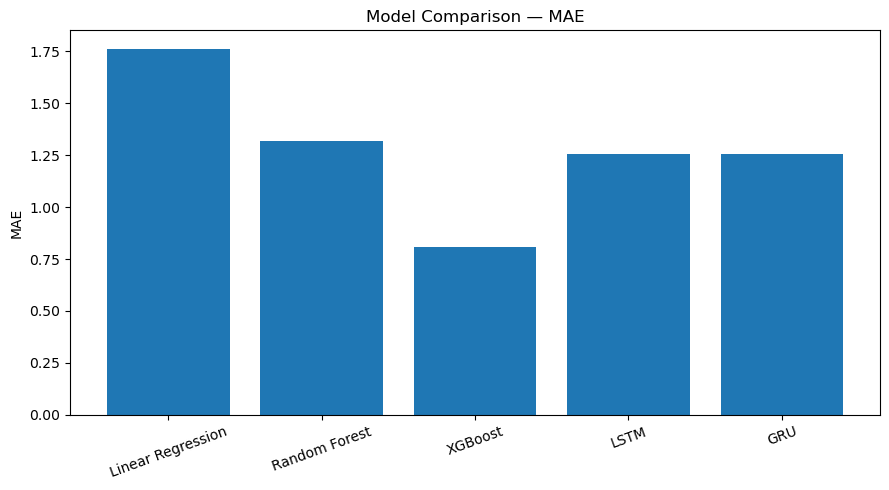

In [23]:
plt.figure(figsize=(9, 5))
plt.bar(comparison_df["Model"], comparison_df["MAE"])
plt.ylabel("MAE")
plt.title("Model Comparison — MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 21. Visual comparison — RMSE

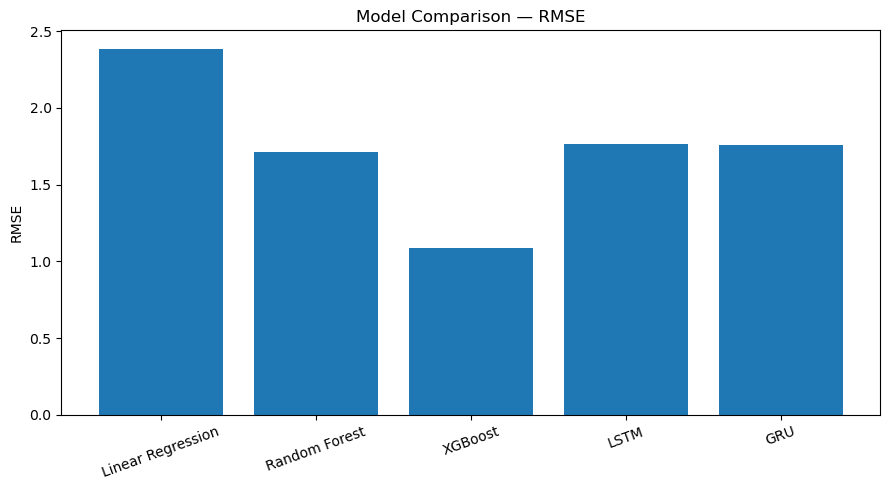

In [24]:
plt.figure(figsize=(9, 5))
plt.bar(comparison_df["Model"], comparison_df["RMSE"])
plt.ylabel("RMSE")
plt.title("Model Comparison — RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 22. Visual comparison — R²

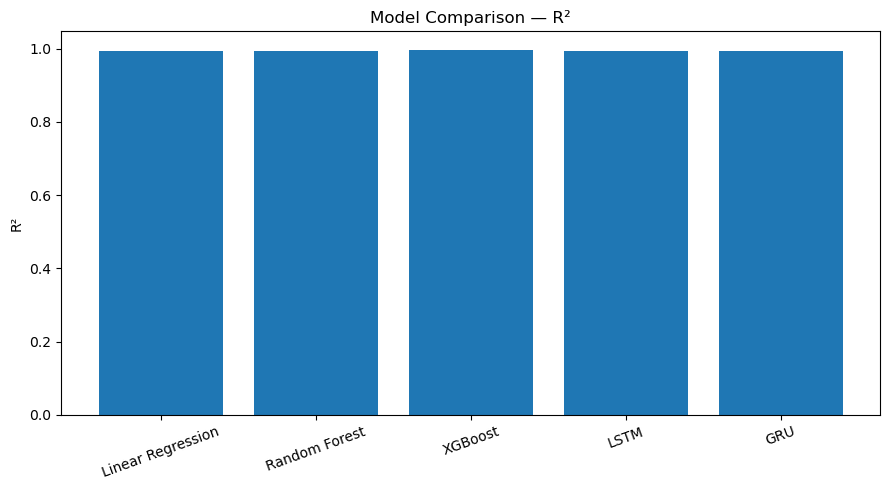

In [25]:
plt.figure(figsize=(9, 5))
plt.bar(comparison_df["Model"], comparison_df["R2"])
plt.ylabel("R²")
plt.title("Model Comparison — R²")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 23. Prediction scatter plot

This checks how closely predicted BPI follows the actual constructed BPI.

We use the combined out-of-fold predictions for the sequence models.

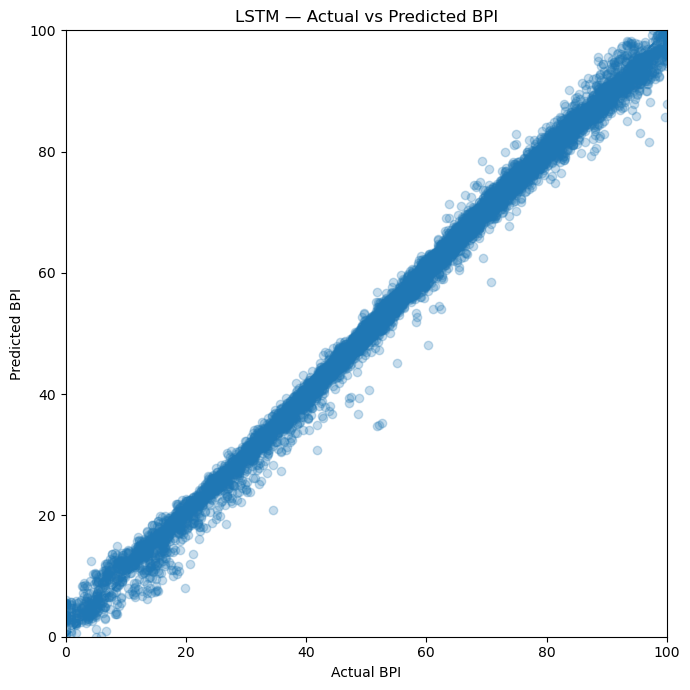

In [26]:
if lstm_predictions:
    lstm_oof = pd.concat(lstm_predictions, ignore_index=True)

    plt.figure(figsize=(7, 7))
    plt.scatter(
        lstm_oof["y_true"],
        lstm_oof["y_pred"],
        alpha=0.25
    )

    plt.plot(
        [0, 100],
        [0, 100],
        linestyle="--"
    )

    plt.xlabel("Actual BPI")
    plt.ylabel("Predicted BPI")
    plt.title("LSTM — Actual vs Predicted BPI")
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

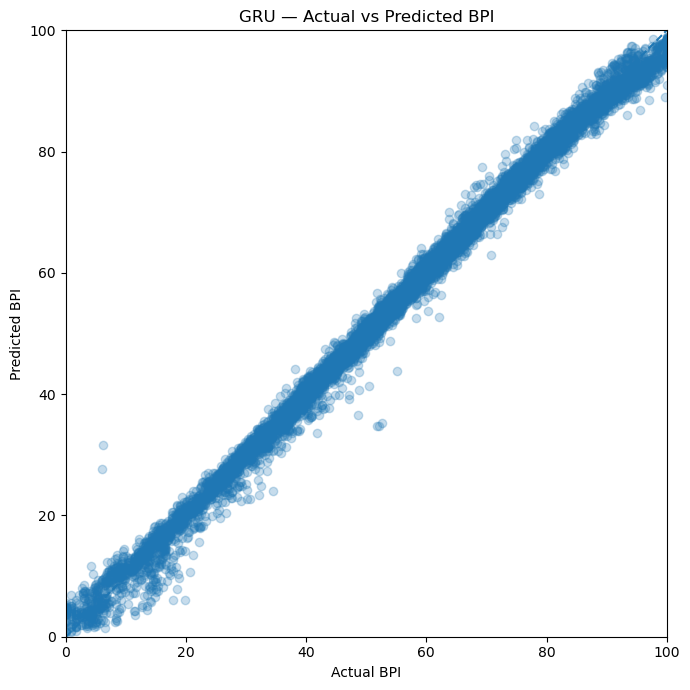

In [27]:
if gru_predictions:
    gru_oof = pd.concat(gru_predictions, ignore_index=True)

    plt.figure(figsize=(7, 7))
    plt.scatter(
        gru_oof["y_true"],
        gru_oof["y_pred"],
        alpha=0.25
    )

    plt.plot(
        [0, 100],
        [0, 100],
        linestyle="--"
    )

    plt.xlabel("Actual BPI")
    plt.ylabel("Predicted BPI")
    plt.title("GRU — Actual vs Predicted BPI")
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

# 24. Residual analysis

Residual:

`actual BPI − predicted BPI`

A residual close to zero means the prediction is close to the constructed target.

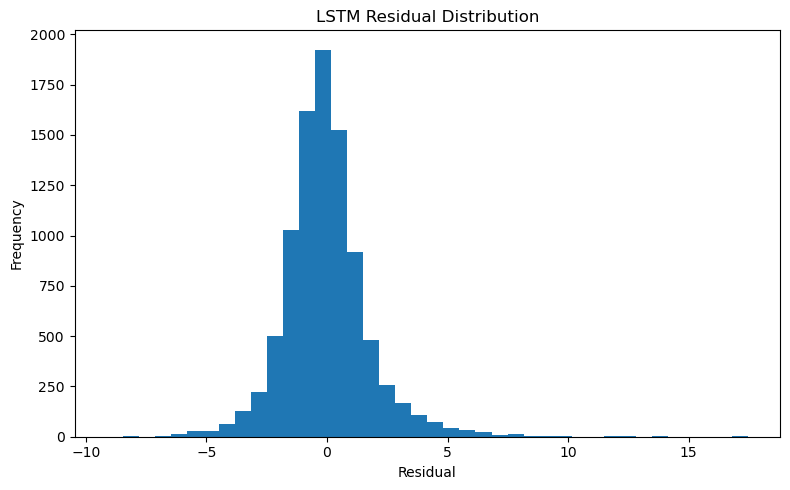

In [28]:
if lstm_predictions:
    residuals = lstm_oof["y_true"] - lstm_oof["y_pred"]

    plt.figure(figsize=(8, 5))
    plt.hist(residuals, bins=40)
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title("LSTM Residual Distribution")
    plt.tight_layout()
    plt.show()

# 25. Sequence length experiment

The first experiment uses sequence length 10.

If the LSTM/GRU results are interesting, the next controlled experiment can test:

- 5 windows
- 10 windows
- 20 windows
- 30 windows

Do not change several hyperparameters simultaneously. Otherwise it becomes difficult to determine why performance changed.

In [29]:
SEQUENCE_LENGTH_OPTIONS = [5, 10, 20, 30]

print("Recommended sequence-length experiments:")
print(SEQUENCE_LENGTH_OPTIONS)

Recommended sequence-length experiments:
[5, 10, 20, 30]


In [30]:
# Sequence lengths to compare
SEQUENCE_LENGTHS = [5, 10, 20, 30]

sequence_length_results = []

print("Testing sequence lengths:", SEQUENCE_LENGTHS)

Testing sequence lengths: [5, 10, 20, 30]


In [31]:
for seq_len in SEQUENCE_LENGTHS:

    print("=" * 80)
    print(f"GRU SEQUENCE LENGTH = {seq_len}")

    fold_results = []

    gkf = GroupKFold(n_splits=5)

    for fold, (train_idx, test_idx) in enumerate(
        gkf.split(df, df[TARGET], groups=df["group_id"]),
        start=1
    ):

        train_df = df.iloc[train_idx].copy()
        test_df = df.iloc[test_idx].copy()

        # ---------------------------------------------------------
        # Verify session-level separation
        # ---------------------------------------------------------
        train_groups = set(train_df["group_id"])
        test_groups = set(test_df["group_id"])

        overlap = train_groups.intersection(test_groups)

        if overlap:
            raise RuntimeError(
                f"Leakage detected in fold {fold}: {overlap}"
            )

        # ---------------------------------------------------------
        # Scale using TRAINING DATA ONLY
        # ---------------------------------------------------------
        scaler = StandardScaler()

        train_df[FEATURES] = scaler.fit_transform(
            train_df[FEATURES]
        )

        test_df[FEATURES] = scaler.transform(
            test_df[FEATURES]
        )

        # ---------------------------------------------------------
        # Create sequences
        # ---------------------------------------------------------
        X_train, y_train, train_sequence_groups = make_sequences(
            train_df,
            FEATURES,
            TARGET,
            sequence_length=seq_len,
            stride=STRIDE
        )

        X_test, y_test, test_sequence_groups = make_sequences(
            test_df,
            FEATURES,
            TARGET,
            sequence_length=seq_len,
            stride=STRIDE
        )

        print(
            f"Fold {fold}: "
            f"Train={X_train.shape}, "
            f"Test={X_test.shape}"
        )

        if len(X_train) == 0 or len(X_test) == 0:
            print("Skipping fold - insufficient sequence length.")
            continue

        # ---------------------------------------------------------
        # Build GRU
        # ---------------------------------------------------------
        model = build_gru_model(
            (X_train.shape[1], X_train.shape[2])
        )

        callbacks = [
            EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True,
                verbose=0
            ),

            ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=2,
                min_lr=1e-6,
                verbose=0
            )
        ]

        # ---------------------------------------------------------
        # Train
        # ---------------------------------------------------------
        history = model.fit(
            X_train,
            y_train,
            validation_split=0.10,
            epochs=30,
            batch_size=64,
            callbacks=callbacks,
            verbose=0
        )

        # ---------------------------------------------------------
        # Predict
        # ---------------------------------------------------------
        y_pred = model.predict(
            X_test,
            verbose=0
        ).reshape(-1)

        y_pred = np.clip(y_pred, 0, 100)

        # ---------------------------------------------------------
        # Metrics
        # ---------------------------------------------------------
        mae = mean_absolute_error(
            y_test,
            y_pred
        )

        mse = mean_squared_error(
            y_test,
            y_pred
        )

        rmse = np.sqrt(mse)

        r2 = r2_score(
            y_test,
            y_pred
        )

        fold_results.append({
            "Sequence_Length": seq_len,
            "Fold": fold,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2,
            "Train_Sequences": len(X_train),
            "Test_Sequences": len(X_test),
            "Epochs_Run": len(history.history["loss"])
        })

        print(
            f"  MAE  = {mae:.4f} | "
            f"RMSE = {rmse:.4f} | "
            f"R²   = {r2:.4f}"
        )

        tf.keras.backend.clear_session()

    # -------------------------------------------------------------
    # Store fold results
    # -------------------------------------------------------------
    sequence_length_results.extend(fold_results)

GRU SEQUENCE LENGTH = 5
Fold 1: Train=(7715, 5, 14), Test=(1933, 5, 14)
  MAE  = 1.5703 | RMSE = 2.2282 | R²   = 0.9919
Fold 2: Train=(7720, 5, 14), Test=(1928, 5, 14)
  MAE  = 1.2869 | RMSE = 1.7542 | R²   = 0.9948
Fold 3: Train=(7719, 5, 14), Test=(1929, 5, 14)
  MAE  = 1.0443 | RMSE = 1.5072 | R²   = 0.9934
Fold 4: Train=(7719, 5, 14), Test=(1929, 5, 14)
  MAE  = 1.1543 | RMSE = 1.5707 | R²   = 0.9958
Fold 5: Train=(7719, 5, 14), Test=(1929, 5, 14)
  MAE  = 1.0020 | RMSE = 1.3686 | R²   = 0.9967
GRU SEQUENCE LENGTH = 10
Fold 1: Train=(7388, 10, 14), Test=(1854, 10, 14)
  MAE  = 1.4342 | RMSE = 2.1743 | R²   = 0.9923
Fold 2: Train=(7395, 10, 14), Test=(1847, 10, 14)
  MAE  = 1.2597 | RMSE = 1.7352 | R²   = 0.9948
Fold 3: Train=(7393, 10, 14), Test=(1849, 10, 14)
  MAE  = 1.0256 | RMSE = 1.4290 | R²   = 0.9939
Fold 4: Train=(7396, 10, 14), Test=(1846, 10, 14)
  MAE  = 1.2858 | RMSE = 1.7257 | R²   = 0.9948
Fold 5: Train=(7396, 10, 14), Test=(1846, 10, 14)
  MAE  = 1.0133 | RMSE = 1.42

In [32]:
sequence_length_results_df = pd.DataFrame(
    sequence_length_results
)

display(
    sequence_length_results_df
)

,Sequence_Length,Fold,MAE,MSE,RMSE,R2,Train_Sequences,Test_Sequences,Epochs_Run
0,5,1,1.570284,4.964896,2.228205,0.991906,7715,1933,19
1,5,2,1.286885,3.077121,1.754172,0.994797,7720,1928,18
2,5,3,1.044288,2.271763,1.507237,0.993415,7719,1929,24
3,5,4,1.154264,2.466951,1.570653,0.995770,7719,1929,17
4,5,5,1.001953,1.873170,1.368638,0.996696,7719,1929,28
5,10,1,1.434216,4.727476,2.174276,0.992334,7388,1854,23
6,10,2,1.259705,3.010824,1.735173,0.994844,7395,1847,20
7,10,3,1.025629,2.041902,1.428951,0.993895,7393,1849,18
8,10,4,1.285844,2.978156,1.725733,0.994836,7396,1846,20
9,10,5,1.013316,2.034776,1.426456,0.996404,7396,1846,26


In [33]:
sequence_summary = (
    sequence_length_results_df
    .groupby("Sequence_Length")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),

        MSE_mean=("MSE", "mean"),
        MSE_std=("MSE", "std"),

        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),

        R2_mean=("R2", "mean"),
        R2_std=("R2", "std")
    )
    .reset_index()
)

display(sequence_summary)

,Sequence_Length,MAE_mean,MAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,5,1.211535,0.228886,2.930780,1.217274,1.685781,0.333397,0.994517,0.001899
1,10,1.203742,0.180954,2.958627,1.098387,1.698118,0.306232,0.994463,0.001492
2,20,1.169605,0.207965,3.051241,1.614463,1.706960,0.414620,0.994104,0.002243
3,30,1.203778,0.255339,3.026601,1.553086,1.698481,0.420957,0.993943,0.002057


In [34]:
sequence_comparison = sequence_summary.copy()

sequence_comparison["MAE"] = (
    sequence_comparison["MAE_mean"].round(4).astype(str)
    + " ± "
    + sequence_comparison["MAE_std"].round(4).astype(str)
)

sequence_comparison["RMSE"] = (
    sequence_comparison["RMSE_mean"].round(4).astype(str)
    + " ± "
    + sequence_comparison["RMSE_std"].round(4).astype(str)
)

sequence_comparison["R²"] = (
    sequence_comparison["R2_mean"].round(4).astype(str)
    + " ± "
    + sequence_comparison["R2_std"].round(4).astype(str)
)

display(
    sequence_comparison[
        ["Sequence_Length", "MAE", "RMSE", "R²"]
    ]
)

,Sequence_Length,MAE,RMSE,R²
0,5,1.2115 ± 0.2289,1.6858 ± 0.3334,0.9945 ± 0.0019
1,10,1.2037 ± 0.181,1.6981 ± 0.3062,0.9945 ± 0.0015
2,20,1.1696 ± 0.208,1.707 ± 0.4146,0.9941 ± 0.0022
3,30,1.2038 ± 0.2553,1.6985 ± 0.421,0.9939 ± 0.0021


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    sequence_summary["Sequence_Length"],
    sequence_summary["RMSE_mean"],
    marker="o"
)

plt.xlabel("Sequence Length")
plt.ylabel("Mean RMSE")
plt.title("GRU Performance vs Sequence Length")
plt.xticks(SEQUENCE_LENGTHS)

plt.tight_layout()
plt.show()

In [ ]:
xgb_rmse = 1.0891
xgb_mae = 0.8064
xgb_r2 = 0.9977

final_sequence_comparison = sequence_summary[
    ["Sequence_Length", "MAE_mean", "RMSE_mean", "R2_mean"]
].copy()

display(final_sequence_comparison)

print("\nXGBoost baseline")
print(f"MAE  : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R²   : {xgb_r2:.4f}")

# 26. Final interpretation

The tested LSTM/GRU configurations did not extract enough additional predictive information from the temporal sequences to outperform XGBoost.


There are several possible reasons:

BPI is already heavily determined by window-level behavioral features.
XGBoost handles the nonlinear relationships between those features very effectively.
The current dataset may be relatively small for deep sequence modeling.
The constructed BPI may not contain strong temporal dependencies.
The tested sequence lengths/architecture may not be optimal.

# 27. Important project limitation

The current target is a **Behavioral Productivity Index constructed from mouse behavior**.

Therefore:

> High model performance means the model can reproduce the constructed BPI accurately.

It does not establish that the model measures true employee productivity.

For stronger validation, future work should compare the BPI/model predictions against independent productivity signals such as:

- task completion time
- completed work/output
- task accuracy
- workflow completion
- human/manager assessment
- application/task context

This distinction should remain explicit in the paper and presentation.